In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neuromusic/avocado-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'avocado-prices' dataset.
Path to dataset files: /kaggle/input/avocado-prices


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
df = pd.read_csv('/kaggle/input/avocado-prices/avocado.csv')
df.head(5)

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [18]:
df = df.drop('Unnamed: 0', axis=1)

In [19]:
df.head(10)

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
5,2015-11-22,1.26,55979.78,1184.27,48067.99,43.61,6683.91,6556.47,127.44,0.0,conventional,2015,Albany
6,2015-11-15,0.99,83453.76,1368.92,73672.72,93.26,8318.86,8196.81,122.05,0.0,conventional,2015,Albany
7,2015-11-08,0.98,109428.33,703.75,101815.36,80.00,6829.22,6266.85,562.37,0.0,conventional,2015,Albany
8,2015-11-01,1.02,99811.42,1022.15,87315.57,85.34,11388.36,11104.53,283.83,0.0,conventional,2015,Albany
9,2015-10-25,1.07,74338.76,842.40,64757.44,113.00,8625.92,8061.47,564.45,0.0,conventional,2015,Albany


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          18249 non-null  object 
 1   AveragePrice  18249 non-null  float64
 2   Total Volume  18249 non-null  float64
 3   4046          18249 non-null  float64
 4   4225          18249 non-null  float64
 5   4770          18249 non-null  float64
 6   Total Bags    18249 non-null  float64
 7   Small Bags    18249 non-null  float64
 8   Large Bags    18249 non-null  float64
 9   XLarge Bags   18249 non-null  float64
 10  type          18249 non-null  object 
 11  year          18249 non-null  int64  
 12  region        18249 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 1.8+ MB


In [20]:
df.groupby('region')['AveragePrice'].mean().sort_values().head()

,AveragePrice
region,
Houston,1.047929
DallasFtWorth,1.085592
SouthCentral,1.101243
CincinnatiDayton,1.209201
Nashville,1.212101


### One-Hot Encoding for Categorical Features

For linear regression models, categorical features like 'type' and 'region' need to be converted into a numerical format. One-hot encoding is a common method for this, where each category is transformed into a new binary column.

In [24]:
df = pd.get_dummies(df, columns=['type', 'region'], drop_first=True)
display(df.head())

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,...,False,False,False,False,False,False,False,False,False,False
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,...,False,False,False,False,False,False,False,False,False,False
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,...,False,False,False,False,False,False,False,False,False,False


In [32]:
X = df.drop(['AveragePrice','Date'], axis=1)
y = df['AveragePrice']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
print("Accuracy: ", model.score(X_test, y_test))

Accuracy:  0.5457525128692868


In [37]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.07298352735665842
R-squared: 0.5457525128692868


### Utilizing Date column

In [38]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

In [39]:
# Extract new features from the 'Date' column
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_year'] = df['Date'].dt.dayofyear
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

display(df[['Date', 'month', 'day_of_week', 'day_of_year', 'week_of_year']].head())

,Date,month,day_of_week,day_of_year,week_of_year
0,2015-12-27,12,6,361,52
1,2015-12-20,12,6,354,51
2,2015-12-13,12,6,347,50
3,2015-12-06,12,6,340,49
4,2015-11-29,11,6,333,48


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 69 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        18249 non-null  datetime64[ns]
 1   AveragePrice                18249 non-null  float64       
 2   Total Volume                18249 non-null  float64       
 3   4046                        18249 non-null  float64       
 4   4225                        18249 non-null  float64       
 5   4770                        18249 non-null  float64       
 6   Total Bags                  18249 non-null  float64       
 7   Small Bags                  18249 non-null  float64       
 8   Large Bags                  18249 non-null  float64       
 9   XLarge Bags                 18249 non-null  float64       
 10  year                        18249 non-null  int64         
 11  type_organic                18249 non-null  bool      

In [44]:
X = df.drop(['AveragePrice', 'Date'], axis=1)
y = df['AveragePrice']

In [45]:
# Resplit
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (14599, 67)
X_test shape: (3650, 67)


In [46]:
# Re-initialize and retrain the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [47]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Re-evaluate the model
print("New Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("New R-squared:", r2_score(y_test, y_pred))

New Mean Squared Error: 0.06632483398184753
New R-squared: 0.5871960391365305


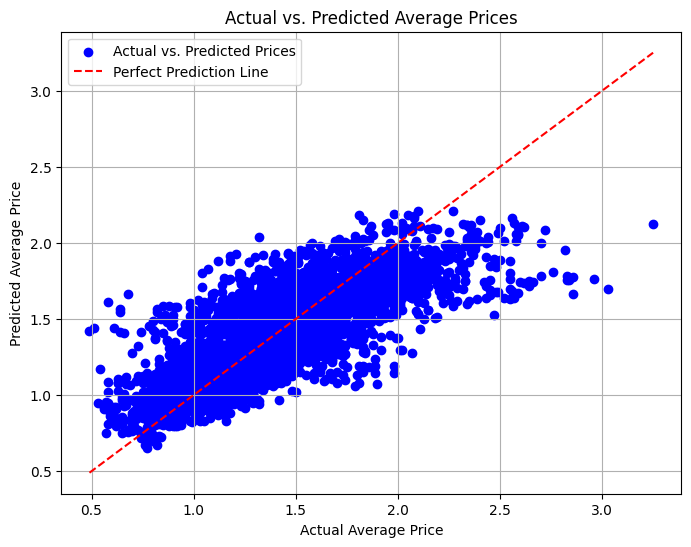

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Average Prices')
plt.xlabel('Actual Average Price')
plt.ylabel('Predicted Average Price')
plt.legend()
plt.grid(True)
plt.show()

## Comparison

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name}: {r2_score(y_test, pred):.4f}")

Linear Regression: 0.5872
Random Forest: 0.9113
Gradient Boosting: 0.7315


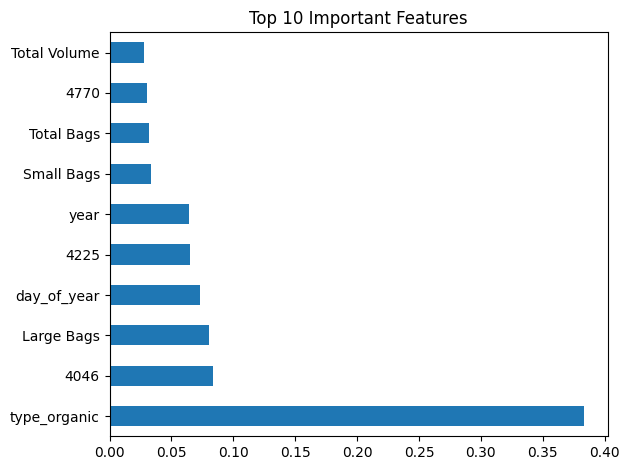

In [53]:
rf = models['Random Forest']
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()